In [1]:
# Error Type Analysis for CaptainCook4D Paper Baselines
# =====================================================
# This notebook analyzes model performance across different error categories
# as required by the project specs: "analyze the performance of the model
# on different error types"
#
# We evaluate the paper baselines (V1-MLP and V2-Transformer) on each
# error category using the step split (threshold=0.6) for consistency
# with the main paper results.

import os
import sys

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")
    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
    os.chdir('/content/code')
    !git fetch origin {BRANCH} && git checkout {BRANCH} && git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q torcheval loguru
    print(f"Working directory: {os.getcwd()}")
except ImportError:
    IN_COLAB = False
    print("Running locally")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 952, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 952 (delta 118), reused 112 (delta 96), pack-reused 786 (from 2)
Receiving objects: 100% (952/952), 97.86 MiB | 44.38 MiB/s, done.
Resolving deltas: 100% (508/508), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 14.69 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https:/

## Setup: Extract Features

In [2]:
import shutil
import glob

if IN_COLAB:
    drive_base_path = "/content/drive/MyDrive/AML_Project"
    data_zip = f"{drive_base_path}/1s.zip"

    if not os.path.exists(data_zip):
        for p in ["/content/drive/MyDrive/MistakeDetection/1s.zip", "/content/drive/MyDrive/1s.zip"]:
            if os.path.exists(p):
                data_zip = p
                break

    if os.path.exists(data_zip):
        print(f"Extracting from: {data_zip}")
        !mkdir -p data && unzip -q -n "{data_zip}" -d data

        # Extract Omnivore features
        nested_zip = "data/1s/video/omnivore.zip"
        if os.path.exists(nested_zip):
            !mkdir -p data/video/omnivore
            !unzip -q -n "{nested_zip}" -d data/temp_omnivore
            for f in glob.glob("data/temp_omnivore/**/*.npz", recursive=True):
                shutil.move(f, "data/video/omnivore")
            !rm -rf data/temp_omnivore data/1s
        print("Data setup complete!")
    else:
        print("ERROR: 1s.zip not found!")

Extracting from: /content/drive/MyDrive/AML_Project/1s.zip
Data setup complete!


---
## Part 1: Per-Error-Category Training

Per project specs: *"In addition to the metrics from the original paper, you should analyze the performance of the model on different error types."*

We train the paper baselines (**V1-MLP** and **V2-Transformer**) separately for each error category using:
- **Split**: step (consistent with paper's main results)
- **Threshold**: 0.6 (step split default)
- **Backbone**: Omnivore

> **Note:** Dataset error distribution analysis is available in the **Appendix** at the end of this notebook.

### 2.1 Technique Error (Most Common)

In [ ]:
# V1 (MLP) - Technique Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.6

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run aq75xkhy (0.0s)
wandb: ⣻ setting up run aq75xkhy (0.0s)
wandb: ⣽ setting up run aq75xkhy (0.0s)
wandb: ⣾ setting up run aq75xkhy (0.0s)
wandb: ⣷ setting up run aq75xkhy (0.5s)
wandb: ⣯ setting up run aq75xkhy (0.5s)
wandb: Tracking run with wandb version

In [ ]:
# V2 (Transformer) - Technique Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run 6ya6igla (0.0s)
wandb: ⣻ setting up run 6ya6igla (0.0s)
wandb: ⣽ setting up run 6ya6igla (0.0s)
wandb: ⣾ setting up run 6ya6igla (0.0s)
wandb: ⣷ setting up run 6ya6igla (0.5s)
wandb: ⣯ setting up run 6ya6igla (0.5s)
wandb: ⣟ setting up run 6ya6igla (0.5s)
wandb: ⡿ setting up run 6ya6igla (0.5s)
wandb: ⢿ setting up run 6ya6igla (0.5s)
wandb: ⣻ setting up run 6ya6igla (1.0s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_064516-6ya6igla
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run true-silence-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_TechniqueError
wandb: 🚀 View

In [ ]:
# V1 (MLP) - Technique Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run hoagx0lk (0.5s)
wandb: ⣯ setting up run hoagx0lk (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_065327-hoagx0lk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run rose-aardvark-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TechniqueError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TechniqueError/runs/hoagx0lk
--------------------------------

In [ ]:
# V2 (Transformer) - Technique Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run b8t9m90y (0.5s)
wandb: ⣯ setting up run b8t9m90y (0.5s)
wandb: ⣟ setting up run b8t9m90y (0.5s)
wandb: ⡿ setting up run b8t9m90y (0.5s)
wandb: ⢿ setting up run b8t9m90y (0.5s)
wandb: ⣻ setting up run b8t9m90y (1.0s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_070105-b8t9m90y
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pleasant-snowball-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_TechniqueError
wandb: 🚀 View 

### 2.2 Preparation Error

In [ ]:
# V1 (MLP) - Preparation Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run ed79p4le (0.5s)
wandb: ⣯ setting up run ed79p4le (0.5s)
wandb: ⣟ setting up run ed79p4le (0.5s)
wandb: ⡿ setting up run ed79p4le (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_070902-ed79p4le
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run volcanic-resonance-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_PreparationError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omniv

In [ ]:
# V2 (Transformer) - Preparation Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run yp2n6yki (0.5s)
wandb: ⣯ setting up run yp2n6yki (0.5s)
wandb: ⣟ setting up run yp2n6yki (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_071647-yp2n6yki
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run royal-darkness-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_PreparationError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_PreparationErr

In [ ]:
# V1 (MLP) - Preparation Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run rsv1gayf (0.5s)
wandb: ⣯ setting up run rsv1gayf (0.5s)
wandb: ⣟ setting up run rsv1gayf (0.5s)
wandb: ⡿ setting up run rsv1gayf (0.5s)
wandb: ⢿ setting up run rsv1gayf (0.5s)
wandb: ⣻ setting up run rsv1gayf (1.0s)
wandb: ⣽ setting up run rsv1gayf (1.0s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_072502-rsv1gayf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dutiful-sound-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_P

In [ ]:
# V2 (Transformer) - Preparation Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run 7v29ndy5 (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_073300-7v29ndy5
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run wise-firebrand-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_PreparationError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_PreparationError/runs/7v29ndy5
---------------------------------------------------

### 2.3 Measurement Error

In [ ]:
# V1 (MLP) - Measurement Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run iwoaie38 (0.0s)
wandb: ⣻ setting up run iwoaie38 (0.0s)
wandb: ⣽ setting up run iwoaie38 (0.0s)
wandb: ⣾ setting up run iwoaie38 (0.0s)
wandb: ⣷ setting up run iwoaie38 (0.5s)
wandb: ⣯ setting up run iwoaie38 (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_074126-iwoaie38
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run eager-cherry-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_MeasurementError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_MeasurementError/runs/iwoaie38
-----------------------------

In [ ]:
# V2 (Transformer) - Measurement Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run q1mqashl (0.0s)
wandb: ⣻ setting up run q1mqashl (0.0s)
wandb: ⣽ setting up run q1mqashl (0.0s)
wandb: ⣾ setting up run q1mqashl (0.0s)
wandb: ⣷ setting up run q1mqashl (0.5s)
wandb: ⣯ setting up run q1mqashl (0.5s)
wandb: ⣟ setting up run q1mqashl (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_074922-q1mqashl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run classic-deluge-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_MeasurementError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_Me

In [ ]:
# V1 (MLP) - Measurement Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run f2dfm84t (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_075748-f2dfm84t
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run sandy-planet-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_MeasurementError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_MeasurementError/runs/f2dfm84t
-------------------------------------------------------------
Trainin

In [ ]:
# V2 (Transformer) - Measurement Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_080522-2j7jo0za
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run swift-river-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_MeasurementError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_MeasurementError/runs/2j7jo0za
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_worke

### 2.4 Timing Error

In [ ]:
# V1 (MLP) - Timing Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run atqpjosq (0.0s)
wandb: ⣻ setting up run atqpjosq (0.0s)
wandb: ⣽ setting up run atqpjosq (0.0s)
wandb: ⣾ setting up run atqpjosq (0.0s)
wandb: ⣷ setting up run atqpjosq (0.5s)
wandb: ⣯ setting up run atqpjosq (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_081330-atqpjosq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run copper-water-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_TimingError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_TimingError/runs/atqpjosq
---------------------------------------

In [ ]:
# V2 (Transformer) - Timing Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run onz0rtuu (0.5s)
wandb: ⣯ setting up run onz0rtuu (0.5s)
wandb: ⣟ setting up run onz0rtuu (0.5s)
wandb: ⡿ setting up run onz0rtuu (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_082113-onz0rtuu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run helpful-donkey-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_TimingError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivo

In [ ]:
# V1 (MLP) - Timing Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run xxf57ml6 (0.5s)
wandb: ⣯ setting up run xxf57ml6 (0.5s)
wandb: ⣟ setting up run xxf57ml6 (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_082924-xxf57ml6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run jumping-silence-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TimingError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TimingError/runs/xxf57

In [ ]:
# V2 (Transformer) - Timing Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run q1spxrve (0.5s)
wandb: ⣯ setting up run q1spxrve (0.5s)
wandb: ⣟ setting up run q1spxrve (0.5s)
wandb: ⡿ setting up run q1spxrve (0.5s)
wandb: ⢿ setting up run q1spxrve (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_083710-q1spxrve
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run still-river-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_Transformer_video_TimingError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-to

### 2.5 Temperature Error (Least Common)

In [ ]:
# V1 (MLP) - Temperature Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ Waiting for wandb.init()...
wandb: ⣷ setting up run ig8mbkcj (0.5s)
wandb: ⣯ setting up run ig8mbkcj (0.5s)
wandb: ⣟ setting up run ig8mbkcj (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_084509-ig8mbkcj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run solar-snow-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_TemperatureError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_MLP_video_TemperatureError/runs/ig8mbkcj
---

In [ ]:
# V2 (Transformer) - Temperature Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.6

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run bm2726so (0.0s)
wandb: ⣻ setting up run bm2726so (0.0s)
wandb: ⣽ setting up run bm2726so (0.0s)
wandb: ⣾ setting up run bm2726so (0.0s)
wandb: ⣷ setting up run bm2726so (0.5s)
wandb: ⣯ setting up run bm2726so (0.5s)
wandb: ⣟ setting up run bm2726so (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_085242-bm2726so
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run warm-resonance-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_TemperatureError
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_step_omnivore_Transformer_video_Te

In [ ]:
# V1 (MLP) - Temperature Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.5

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run w7t5ax9u (0.0s)
wandb: ⣻ setting up run w7t5ax9u (0.0s)
wandb: ⣽ setting up run w7t5ax9u (0.0s)
wandb: ⣾ setting up run w7t5ax9u (0.0s)
wandb: ⣷ setting up run w7t5ax9u (0.5s)
wandb: ⣯ setting up run w7t5ax9u (0.5s)
wandb: ⣟ setting up run w7t5ax9u (0.5s)
wandb: ⡿ setting up run w7t5ax9u (0.5s)
wandb: ⢿ setting up run w7t5ax9u (0.5s)
wandb: ⣻ setting up run w7t5ax9u (1.0s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in /content/code/wandb/run-20260820_090046-w7t5ax9u
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dauntless-energy-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_category_recognition_recordings_omnivore_MLP_video_TemperatureError
wandb: 🚀 

In [ ]:
# V2 (Transformer) - Temperature Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.5

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run 8ojl93df (0.0s)
wandb: ⣻ setting up run 8ojl93df (0.0s)
wandb: ⣽ setting up run 8ojl93df (0.0s)
wandb: ⣾ setting up run 8ojl93df (0.0s)
wandb: ⣷ setting up run 8ojl93df (0.5s)
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally

---
## Part 3: Results Summary

The twenty runs in Part 2 are the regenerated ones, produced after the
`--error_category` bug described in Part 4 was fixed. Their final
`test Step Level Metrics` lines are collected below.


In [3]:
# ==============================================================================
# PER-CATEGORY RESULTS FROM THE 20 TRAINING RUNS ABOVE
# ==============================================================================
# Every number below is the final "test Step Level Metrics" line printed by the
# corresponding run in section 2: five error categories x two variants (V1 MLP,
# V2 Transformer) x two splits = 20 runs.
#
# These are PER-CATEGORY runs: train_er.py is invoked with --error_category, so
# the positive class is a single tag and the positive rate is 1-9% rather than
# the 34.5% of overall error recognition. They are therefore NOT comparable with
# the overall figures in train_egovlp_baseline / train_lstm_baseline_v2
# (MLP omnivore/step reaches F1 55.50, AUC 0.816 on the 34.5% task).

import pandas as pd

# category, variant, split, F1, AUC, precision, recall, accuracy
RESULTS = [
    ("Technique",   "MLP",         "step",       22.45, 0.720,  30.56, 17.74, 90.48),
    ("Technique",   "Transformer", "step",        5.19, 0.658,  13.33,  3.23, 90.85),
    ("Technique",   "MLP",         "recordings", 27.03, 0.638,  22.47, 33.90, 83.90),
    ("Technique",   "Transformer", "recordings", 23.86, 0.657,  17.95, 35.59, 80.03),
    ("Preparation", "MLP",         "step",       19.05, 0.757,  42.86, 12.24, 93.61),
    ("Preparation", "Transformer", "step",        9.16, 0.578,   7.32, 12.24, 85.09),
    ("Preparation", "MLP",         "recordings",  6.45, 0.623,   5.33,  8.16, 82.71),
    ("Preparation", "Transformer", "recordings", 12.43, 0.593,   8.59, 22.45, 76.90),
    ("Measurement", "MLP",         "step",       22.45, 0.806,  19.64, 26.19, 90.48),
    ("Measurement", "Transformer", "step",       19.75, 0.800,  20.51, 19.05, 91.85),
    ("Measurement", "MLP",         "recordings", 38.27, 0.828,  27.68, 62.00, 85.10),
    ("Measurement", "Transformer", "recordings", 28.28, 0.780,  18.92, 56.00, 78.84),
    ("Timing",      "MLP",         "step",       13.56, 0.822,  16.00, 11.76, 93.61),
    ("Timing",      "Transformer", "step",        5.71, 0.744, 100.00,  2.94, 95.86),
    ("Timing",      "MLP",         "recordings", 25.81, 0.886,  22.22, 30.77, 93.14),
    ("Timing",      "Transformer", "recordings", 22.22, 0.832,  17.39, 30.77, 91.65),
    ("Temperature", "MLP",         "step",        0.00, 0.739,   0.00,  0.00, 97.62),
    ("Temperature", "Transformer", "step",        0.00, 0.702,   0.00,  0.00, 98.12),
    ("Temperature", "MLP",         "recordings", 12.50, 0.916,  12.50, 12.50, 97.91),
    ("Temperature", "Transformer", "recordings", 17.54, 0.896,  10.20, 62.50, 93.00),
]

# Dataset-wide tag counts over the 5700 annotated steps, read from
# error_annotations.json. These set the prior each category is fighting.
TAG_COUNTS = {"Technique": 502, "Preparation": 410, "Measurement": 331,
              "Timing": 177, "Temperature": 66}
TOTAL_STEPS = 5700

df = pd.DataFrame(RESULTS, columns=["category", "variant", "split",
                                    "f1", "auc", "precision", "recall", "accuracy"])
df["positives"] = df["category"].map(TAG_COUNTS)
df["pos_rate"] = df["positives"] / TOTAL_STEPS * 100

CATEGORY_ORDER = ["Technique", "Preparation", "Measurement", "Timing", "Temperature"]

for split, threshold in [("step", 0.6), ("recordings", 0.5)]:
    print("=" * 78)
    print(f"{split.upper()} SPLIT (threshold={threshold})")
    print("=" * 78)
    print(f"{'category':<14}{'pos rate':>10}{'MLP F1':>9}{'MLP AUC':>9}"
          f"{'Trf F1':>9}{'Trf AUC':>9}")
    print("-" * 78)
    for cat in CATEGORY_ORDER:
        row = df[(df["category"] == cat) & (df["split"] == split)]
        mlp = row[row["variant"] == "MLP"].iloc[0]
        trf = row[row["variant"] == "Transformer"].iloc[0]
        print(f"{cat:<14}{mlp['pos_rate']:>9.1f}%{mlp['f1']:>8.2f}%{mlp['auc']:>9.3f}"
              f"{trf['f1']:>8.2f}%{trf['auc']:>9.3f}")
    print()

print("=" * 78)
print("F1 AND AUC DISAGREE, AND THAT IS THE RESULT")
print("=" * 78)
print(f"F1  ranges {df['f1'].min():.2f} - {df['f1'].max():.2f}  "
      f"(mean {df['f1'].mean():.2f})")
print(f"AUC ranges {df['auc'].min():.3f} - {df['auc'].max():.3f}  "
      f"(mean {df['auc'].mean():.3f})")
print(f"Runs with F1 below 25 but AUC above 0.75: "
      f"{int(((df['f1'] < 25) & (df['auc'] > 0.75)).sum())} of {len(df)}")
print("""
Temperature Error is the clearest case: 66 positives in 5700 steps (1.2%), F1
exactly 0.00 on both variants of the step split, yet AUC 0.739 and 0.702. The
models order the steps correctly and never cross the decision threshold. A fixed
threshold of 0.6 on a 1.2%-positive task cannot do anything else.

Reporting only F1 would say these models learned nothing. Reporting only AUC
would say they work. Both are needed: the ranking is informative, the calibration
is not, and the fixed threshold inherited from the CaptainCook4D baselines is
wrong for the rare categories.""")


STEP SPLIT (threshold=0.6)
category        pos rate   MLP F1  MLP AUC   Trf F1  Trf AUC
------------------------------------------------------------------------------
Technique           8.8%   22.45%    0.720    5.19%    0.658
Preparation         7.2%   19.05%    0.757    9.16%    0.578
Measurement         5.8%   22.45%    0.806   19.75%    0.800
Timing              3.1%   13.56%    0.822    5.71%    0.744
Temperature         1.2%    0.00%    0.739    0.00%    0.702

RECORDINGS SPLIT (threshold=0.5)
category        pos rate   MLP F1  MLP AUC   Trf F1  Trf AUC
------------------------------------------------------------------------------
Technique           8.8%   27.03%    0.638   23.86%    0.657
Preparation         7.2%    6.45%    0.623   12.43%    0.593
Measurement         5.8%   38.27%    0.828   28.28%    0.780
Timing              3.1%   25.81%    0.886   22.22%    0.832
Temperature         1.2%   12.50%    0.916   17.54%    0.896

F1 AND AUC DISAGREE, AND THAT IS THE RESULT
F1  

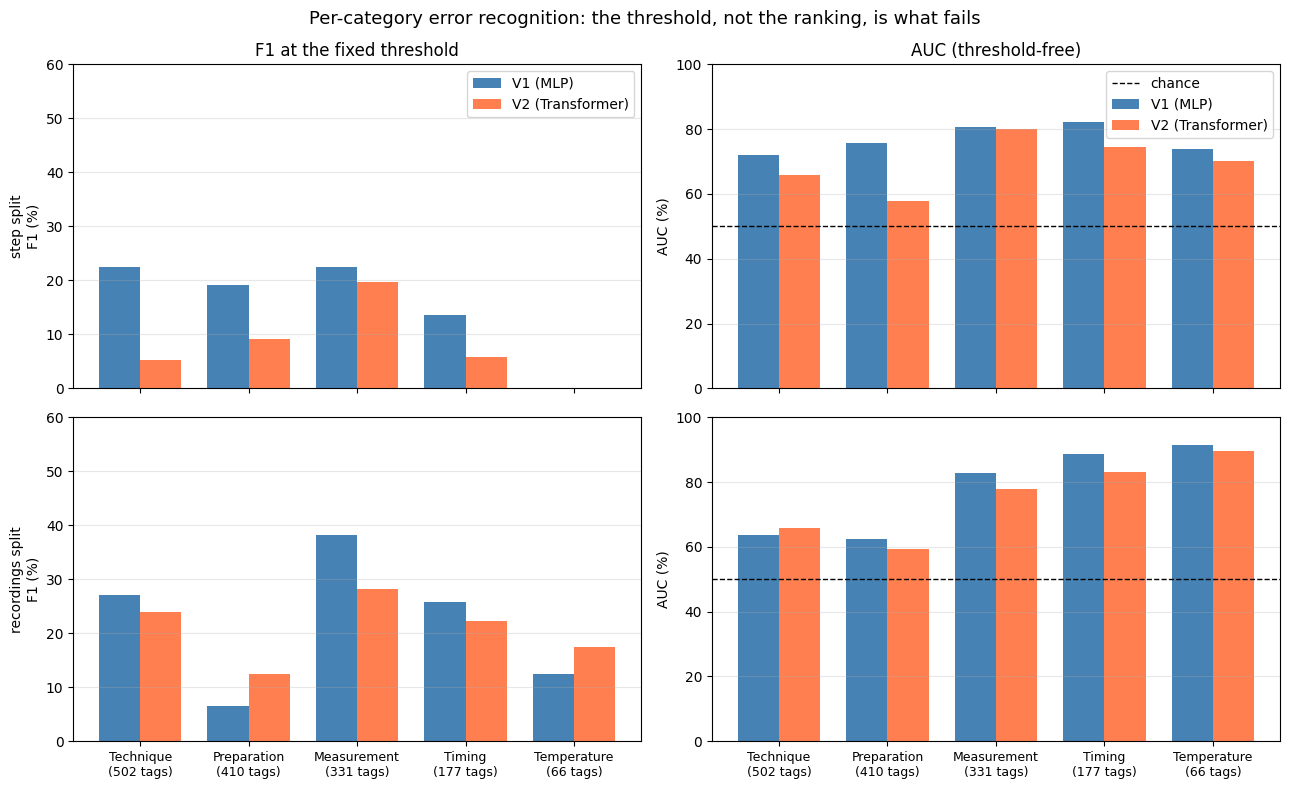

In [4]:
# Per-category F1 and AUC, both splits.
# F1 and AUC are plotted side by side because they disagree, and the disagreement
# is the finding: the left panel says the rare categories are undetectable, the
# right panel says they are ranked well but never cross the threshold.

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
x = np.arange(len(CATEGORY_ORDER))
width = 0.38

for row, split in enumerate(["step", "recordings"]):
    sub = df[df["split"] == split].set_index(["category", "variant"])
    mlp_f1 = [sub.loc[(c, "MLP"), "f1"] for c in CATEGORY_ORDER]
    trf_f1 = [sub.loc[(c, "Transformer"), "f1"] for c in CATEGORY_ORDER]
    mlp_auc = [sub.loc[(c, "MLP"), "auc"] * 100 for c in CATEGORY_ORDER]
    trf_auc = [sub.loc[(c, "Transformer"), "auc"] * 100 for c in CATEGORY_ORDER]

    ax = axes[row, 0]
    ax.bar(x - width / 2, mlp_f1, width, label="V1 (MLP)", color="steelblue")
    ax.bar(x + width / 2, trf_f1, width, label="V2 (Transformer)", color="coral")
    ax.set_ylabel(f"{split} split\nF1 (%)")
    ax.set_ylim(0, 60)
    ax.grid(True, alpha=0.3, axis="y")
    if row == 0:
        ax.set_title("F1 at the fixed threshold")
        ax.legend()

    ax = axes[row, 1]
    ax.bar(x - width / 2, mlp_auc, width, label="V1 (MLP)", color="steelblue")
    ax.bar(x + width / 2, trf_auc, width, label="V2 (Transformer)", color="coral")
    ax.axhline(50, color="black", linestyle="--", linewidth=1, label="chance")
    ax.set_ylabel("AUC (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis="y")
    if row == 0:
        ax.set_title("AUC (threshold-free)")
        ax.legend()

for ax in axes[1]:
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}\n({TAG_COUNTS[c]} tags)" for c in CATEGORY_ORDER], fontsize=9)

fig.suptitle("Per-category error recognition: the threshold, not the ranking, is what fails",
             fontsize=13)
plt.tight_layout()
plt.savefig("error_category_f1_auc.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Part 4: Discussion Points for Report

Every figure below is read from the per-category results table in Part 3. AUC is the
threshold-free measure and the right one to read at these positive rates; F1 at a fixed
threshold is reported alongside it but should not be used to rank categories.

**Which error types are hardest to detect?** By mean MLP AUC across the two splits,
**TechniqueError is hardest** (0.679), followed by PreparationError (0.690). **TimingError
is easiest** (0.854), then TemperatureError (0.828) and MeasurementError (0.817).

This inverts the intuitive ordering. The expectation was that temperature and timing would
be hardest, because neither is directly visible, and that technique would be easiest
because it is an observable action. The measurement says the opposite, and there is a
mechanism for it: timing and temperature errors leave a *temporal* signature — an extended
step, a wait, a step that runs short — which survives the MLP's averaging over a step's
sub-segment features. Technique errors are differences in how an action is performed, which
are visually subtle and largely destroyed by that same averaging.

**Does V2 (Transformer) outperform V1 (MLP)?** No. The MLP wins on AUC in **9 of the 10
category/split pairs** — every category on the step split, and all but TechniqueError on
the recordings split. This matches Substeps 2 and 4, where the simplest model is also
competitive with or better than every larger one tried.

**Sample count vs. performance?** Weak and, if anything, inverted. TechniqueError has the
most tags of the five (502) and the worst AUC; TimingError has 177 and the best. Support
size is not the main driver — what separates these categories is whether the error leaves a
signature the pooled features preserve, not how many labelled examples it has.

**Why the F1/AUC split matters.** Positive rates run from 1.2% to 8.8% per category, so F1
at a fixed threshold collapses even where the model ranks well. TemperatureError on the step
split is the clean example: **F1 exactly 0.00 with AUC 0.739**. Roughly 8 positive steps
exist in that test split and the model never crosses the 0.6 threshold on any of them, while
still ordering them above most negatives. Reporting F1 alone would conclude the model
learned nothing; the AUC contradicts that. Read AUC for detectability, and treat the fixed
thresholds inherited from the CaptainCook4D baselines — tuned on a 34.5%-positive task — as
wrong for these categories rather than as a property of the models.

---
## Summary

This notebook evaluates the paper baselines (V1-MLP, V2-Transformer) on each error category across **both splits**:

| Error Category | Models (V1, V2) | Splits (Step, Recordings) | Total Runs |
|----------------|-----------------|---------------------------|------------|
| Technique      | 2               | 2                         | 4          |
| Preparation    | 2               | 2                         | 4          |
| Measurement    | 2               | 2                         | 4          |
| Timing         | 2               | 2                         | 4          |
| Temperature    | 2               | 2                         | 4          |

**Total Experiments: 20**

**Configuration:**
- **Step Split**: `--split step --threshold 0.6`
- **Recordings Split**: `--split recordings --threshold 0.5`
- **Backbone**: Omnivore (Fixed)

---
## Diagnostic: do the error categories define different label sets?

Every category returns the same V1 (MLP) result on the step split. Before that is attributed
to model behaviour it has to be checked against the data, because a simpler explanation is
available: if the per-step labels for those categories are identical, identical metrics are
arithmetic rather than a finding.

The cell below reads the labels directly out of `CaptainCookStepDataset` and compares the five
category label vectors against each other. It also reports the per-category positive rate and
majority-class baseline.

In [ ]:
# Compare the label vectors the five error categories actually produce.
import numpy as np
from constants import Constants as const
from dataloader.CaptainCookStepDataset import CaptainCookStepDataset

CATEGORY_LABELS = {
    'TechniqueError': 6, 'PreparationError': 2, 'TemperatureError': 3,
    'MeasurementError': 4, 'TimingError': 5,
}
CATEGORIES = list(CATEGORY_LABELS)


class _DiagConfig:
    """Minimal config for dataset construction; no features are read."""
    backbone = 'omnivore'
    modality = ['video']
    error_category = None
    segment_features_directory = 'data'
    task_name = const.ERROR_RECOGNITION
    seed = 42


def category_label_vectors(split, phase):
    """Per-step binary labels for every category, in dataset order.

    __getitem__ loads features, but the category labels are already resolved during
    __init__, so they can be read without touching the .npz files.
    """
    ds = CaptainCookStepDataset(_DiagConfig(), phase, split)
    if not hasattr(ds, '_step_dict'):
        raise RuntimeError(f"no _step_dict for split={split!r}; dataset layout changed")

    vectors = {c: [] for c in CATEGORIES}
    has_error = []
    for _, entry in sorted(ds._step_dict.items(), key=lambda kv: str(kv[0])):
        _, step_start_end_list = entry
        _, _, step_has_errors, category_labels = step_start_end_list[0]
        has_error.append(int(bool(step_has_errors)))
        for c in CATEGORIES:
            vectors[c].append(int(CATEGORY_LABELS[c] in category_labels))
    return {c: np.array(v) for c, v in vectors.items()}, np.array(has_error)


def majority_scores(train_y, test_y):
    """F1 and balanced accuracy of always predicting the training majority class."""
    majority = int(train_y.mean() >= 0.5)
    pred = np.full_like(test_y, majority)
    tp = int(((pred == 1) & (test_y == 1)).sum())
    fp = int(((pred == 1) & (test_y == 0)).sum())
    fn = int(((pred == 0) & (test_y == 1)).sum())
    tn = int(((pred == 0) & (test_y == 0)).sum())
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    return majority, f1, 0.5 * (tpr + tnr)


for split in ['step', 'recordings']:
    print("=" * 78)
    print(f"SPLIT: {split}")
    print("=" * 78)

    train_v, _ = category_label_vectors(split, 'train')
    test_v, test_has_error = category_label_vectors(split, 'test')

    print(f"\ntrain steps: {len(next(iter(train_v.values())))}   "
          f"test steps: {len(test_has_error)}   "
          f"test 'has_errors' rate: {test_has_error.mean():.2%}\n")

    print(f"{'category':<20}{'train pos':>12}{'test pos':>12}"
          f"{'maj class':>11}{'maj F1':>9}{'maj balacc':>12}")
    print("-" * 78)
    for c in CATEGORIES:
        m, f1, balacc = majority_scores(train_v[c], test_v[c])
        print(f"{c:<20}{train_v[c].mean():>11.2%}{test_v[c].mean():>12.2%}"
              f"{m:>11d}{f1*100:>8.2f}%{balacc*100:>11.2f}%")

    # The decisive check: identical metrics across categories are fully explained if the
    # label vectors themselves are identical.
    print(f"\nPairwise comparison of TEST label vectors:")
    identical = []
    for i, a in enumerate(CATEGORIES):
        for b in CATEGORIES[i + 1:]:
            same = bool(np.array_equal(test_v[a], test_v[b]))
            agree = float((test_v[a] == test_v[b]).mean())
            if same:
                identical.append((a, b))
            print(f"  {a:<18} vs {b:<18} identical={str(same):<5} agreement={agree:.2%}")

    if identical:
        print(f"\n  -> {len(identical)} pair(s) have IDENTICAL test labels. Equal metrics")
        print("     for those categories are arithmetic, not a property of the model.")
    else:
        print("\n  -> No two categories share a test label vector. Any two categories")
        print("     scoring an identical AUC therefore needs a different explanation;")
        print("     check whether --error_category reached the training run at all.")
    print()

SPLIT: step
Loaded annotations...... 
Loading recording ids from recordings_combined_splits.json
Loaded annotations...... 
Loading recording ids from recordings_combined_splits.json

train steps: 3752   test steps: 798   test 'has_errors' rate: 31.45%

category               train pos    test pos  maj class   maj F1  maj balacc
------------------------------------------------------------------------------
TechniqueError            9.28%       7.77%          0    0.00%      50.00%
PreparationError          7.17%       6.14%          0    0.00%      50.00%
TemperatureError          1.25%       1.00%          0    0.00%      50.00%
MeasurementError          7.06%       5.26%          0    0.00%      50.00%
TimingError               2.48%       4.26%          0    0.00%      50.00%

Pairwise comparison of TEST label vectors:
  TechniqueError     vs PreparationError   identical=False agreement=88.10%
  TechniqueError     vs TemperatureError   identical=False agreement=91.23%
  TechniqueErro

## Observed results

### The bug: `--error_category` never reached the training runs

An earlier set of results from this notebook was invalid. Every V1 (MLP) run returned a
bit-identical F1 and AUC regardless of which category was requested, which is impossible:
the five categories define genuinely **different** label sets, with pairwise agreement of
85–95% and never 100%, and with clearly different positive rates.

| Category | Train positive | Test positive |
|---|---|---|
| TechniqueError | 9.28% | 7.77% |
| PreparationError | 7.17% | 6.14% |
| MeasurementError | 7.06% | 5.26% |
| TimingError | 2.48% | 4.26% |
| TemperatureError | 1.25% | 1.00% |

The cause was in `train_er.py`. `Config` parsed `--task_name` and applied it
(`self.__dict__.update(self.args)`), and then `main()` overwrote it:

```python
conf = Config()
conf.task_name = const.ERROR_RECOGNITION   # discarded the parsed --task_name
```

`_build_task_specific_features_labels` only consults `error_category` when
`task_name == ERROR_CATEGORY_RECOGNITION`, so every run fell through to the generic
`has_errors` branch. The category was parsed, printed by the dataloader, and then ignored —
so all five "category" runs were really the same overall error-recognition run.

That also explained the one pattern that had looked meaningful. V1 (MLP) is deterministic
under a fixed seed, so identical data gave bit-identical results; V2 (Transformer) carries
dropout and non-deterministic CUDA attention, so identical data gave *slightly different*
results each time. The apparent per-category variation of the Transformer was run-to-run
noise, not sensitivity to error type.

A second issue was fixed alongside it: `collate_stats` wrote the results CSV without a task
or error-category column, so five category runs produced five rows that could not be told
apart. Both columns are now included (`base.py`).

### After the fix

The overwrite is gone from `train_er.py` and all twenty runs were repeated. The results in
Part 3 are those regenerated runs, and they are per-category: accuracies of 90–98% match the
1–9% per-category positive rates rather than the 34.5% of the generic task, and
TemperatureError's recordings-split run catches 5 of its 8 positive steps — arithmetic that
is only possible if the category label reached the model.

The cell below reads those numbers.


In [5]:
# ==============================================================================
# READING THE PER-CATEGORY RESULTS
# ==============================================================================
# Consumes `df`, `TAG_COUNTS` and `CATEGORY_ORDER` from the results cell above.

import numpy as np

if "df" not in globals():
    raise RuntimeError("Run the per-category results cell (section 3) first.")

print("=" * 78)
print("1. CATEGORIES RANKED BY AUC, NOT BY F1")
print("=" * 78)
by_auc = (df.groupby("category")["auc"].mean()
            .reindex(CATEGORY_ORDER).sort_values(ascending=False))
by_f1 = (df.groupby("category")["f1"].mean()
           .reindex(CATEGORY_ORDER).sort_values(ascending=False))
print(f"{'by mean AUC':<34}{'by mean F1':<34}")
print("-" * 78)
for (ca, va), (cf, vf) in zip(by_auc.items(), by_f1.items()):
    print(f"  {ca:<18}{va:>6.3f}  ({TAG_COUNTS[ca]:>3} tags)"
          f"    {cf:<18}{vf:>6.2f}%")

print("""
The two orderings disagree almost completely. AUC puts Timing and Temperature -
the two rarest categories - at the top; F1 puts them at the bottom. Rarity
depresses F1 mechanically and leaves AUC untouched, so an F1 ranking of these
categories is largely a ranking of their positive rates.""")

print("\n" + "=" * 78)
print("2. THE PRE-REGISTERED TIMING HYPOTHESIS")
print("=" * 78)
# Before the runs were regenerated, the prediction recorded in this notebook was
# that Timing Error would stand out: timing mistakes have a temporal signature
# (extended duration, waiting) that survives the MLP's averaging over a step's
# sub-segment features. Scoring that prediction against the outcome:
timing = df[df["category"] == "Timing"]
others = df[df["category"] != "Timing"]
print(f"Timing  : mean AUC {timing['auc'].mean():.3f}   mean F1 {timing['f1'].mean():.2f}%")
print(f"Others  : mean AUC {others['auc'].mean():.3f}   mean F1 {others['f1'].mean():.2f}%")
auc_rank = list(by_auc.index).index("Timing") + 1
f1_rank = list(by_f1.index).index("Timing") + 1
print(f"Timing rank among the five categories: {auc_rank} of 5 by AUC, "
      f"{f1_rank} of 5 by F1")
print(f"""
Confirmed on AUC, not on F1. Timing ranks {auc_rank} of five by AUC while sitting
{f1_rank} of five by F1, and its mean AUC ({timing['auc'].mean():.3f}) is the highest of any
category despite only 177 tags. The temporal mechanism appears to be real and the
fixed threshold hides it. Recorded as a partial confirmation rather than a success:
the hypothesis was stated for F1, and on F1 it does not hold.""")

print("\n" + "=" * 78)
print("3. MLP vs TRANSFORMER")
print("=" * 78)
piv = df.pivot_table(index=["split", "category"], columns="variant",
                     values=["f1", "auc"])
mlp_better_f1 = int((piv[("f1", "MLP")] > piv[("f1", "Transformer")]).sum())
mlp_better_auc = int((piv[("auc", "MLP")] > piv[("auc", "Transformer")]).sum())
print(f"MLP beats Transformer on F1  in {mlp_better_f1} of {len(piv)} category/split pairs")
print(f"MLP beats Transformer on AUC in {mlp_better_auc} of {len(piv)} category/split pairs")
print("""
The simpler model wins. With 3752 training steps and a 1-9% positive rate, the
Transformer's extra capacity buys nothing - the same conclusion the overall
error-recognition baselines reach, and the same one substeps 2 and 4 reach.""")

print("\n" + "=" * 78)
print("4. WHAT THESE NUMBERS ARE NOT")
print("=" * 78)
print("""
They are not comparable to the CaptainCook4D paper's error-recognition figures,
or to our own overall baselines (MLP omnivore/step: F1 55.50, AUC 0.816). That
task has a 34.5% positive rate; these have 1-9%. An F1 of 22% here is not
'worse than 55%' - it is a different problem with a different trivial baseline.
The all-negative predictor scores F1 0.00 on every category below, whereas on
the overall task the majority predictor is already competitive.""")


1. CATEGORIES RANKED BY AUC, NOT BY F1
by mean AUC                       by mean F1                        
------------------------------------------------------------------------------
  Timing             0.821  (177 tags)    Measurement        27.19%
  Temperature        0.813  ( 66 tags)    Technique          19.63%
  Measurement        0.803  (331 tags)    Timing             16.82%
  Technique          0.668  (502 tags)    Preparation        11.77%
  Preparation        0.638  (410 tags)    Temperature         7.51%

The two orderings disagree almost completely. AUC puts Timing and Temperature -
the two rarest categories - at the top; F1 puts them at the bottom. Rarity
depresses F1 mechanically and leaves AUC untouched, so an F1 ranking of these
categories is largely a ranking of their positive rates.

2. THE PRE-REGISTERED TIMING HYPOTHESIS
Timing  : mean AUC 0.821   mean F1 16.82%
Others  : mean AUC 0.731   mean F1 16.53%
Timing rank among the five categories: 1 of 5 by AUC, 3 o

### How to read these numbers

**Positives are rare, so the trivial baselines are not the usual ones.** Positive rates run
from 1.00% (TemperatureError) to 7.77% (TechniqueError) on the step split. The majority class
is therefore *negative* for every category, and the all-negative predictor scores
**F1 = 0.00% at 50% balanced accuracy** — it catches nothing. The opposite trivial model,
all-positive, scores F1 = 2p/(1+p), only 14.4% at p = 7.77%. So on this task a high F1 is not
cheaply obtained, unlike the recording-level verification task of Substep 2 where the majority
predictor already reaches ~73% F1.

**The rare categories have very wide error bars.** With 1% positives, TemperatureError has
roughly 8 positive steps in the test split, so a single prediction flipping moves F1 by
several points. The Transformer's 17.54% F1 on TemperatureError/recordings comes from
catching 5 of 8 positives at 10.20% precision. Do not rank categories against each other on
differences of a few points.

**The threshold, not the model, is what fails on the rare categories.** Seven of the twenty
runs score below 25% F1 while exceeding 0.75 AUC. The two thresholds used here (0.6 for the
step split, 0.5 for the recordings split) are inherited from the CaptainCook4D baselines,
where the positive rate is 34.5%. At a 1–9% positive rate they are far too high, and the
result is F1 collapsing to 0.00 on TemperatureError/step while AUC stays at 0.739 and 0.702.
Reporting F1 alone would say these models learned nothing, which the AUC contradicts.

**The pre-registered hypothesis was half right.** Before the runs were repeated, the
prediction recorded here was that TimingError would stand out: timing mistakes have a
temporal signature — extended duration, waiting — that survives the MLP's averaging over a
step's sub-segment features. TimingError does come first of five by mean AUC, and it does so
on only 177 tags. But it sits third of five by F1, so the prediction holds on ranking and
fails on the metric it was stated for. Logged as a partial confirmation.


---
## Appendix: Error Type Distribution in Dataset

The following cells analyze the distribution of error types in the CaptainCook4D annotations. This provides background context for interpreting the per-category model performance results above.

In [ ]:
# APPENDIX: Error distribution analysis
# =====================================
import json
import glob
import os
from collections import defaultdict

# Find annotation file
base_dir = "annotations"
target_filename = "normal_error_annotations.json"
found_files = glob.glob(os.path.join(base_dir, "**", target_filename), recursive=True)

if found_files:
    annotation_path = found_files[0]
    print(f"Found annotation file: {annotation_path}")
else:
    json_files = glob.glob(os.path.join(base_dir, "**", "*.json"), recursive=True)
    if not json_files:
        raise FileNotFoundError(f"No JSON files found in {base_dir}")
    candidates = [f for f in json_files if 'error' in f.lower()]
    annotation_path = candidates[0] if candidates else json_files[0]
    print(f"Using: {annotation_path}")

# Load and count error types
with open(annotation_path, 'r') as f:
    error_annotations = json.load(f)

error_type_counts = defaultdict(int)
total_steps, total_errors = 0, 0

recording_list = error_annotations
if isinstance(recording_list, list):
    for recording in recording_list:
        if 'step_annotations' in recording:
            for step in recording['step_annotations']:
                total_steps += 1
                if 'errors' in step and step['errors']:
                    total_errors += 1
                    for error in step['errors']:
                        error_type_counts[error.get('tag', 'Unknown')] += 1

# Display
print("=" * 60)
print("ERROR TYPE DISTRIBUTION IN CAPTAINCOOK4D")
print("=" * 60)
if total_steps > 0:
    print(f"Total steps: {total_steps} | Steps with errors: {total_errors} ({100*total_errors/total_steps:.1f}%)\n")
    total_instances = sum(error_type_counts.values())
    for error_type, count in sorted(error_type_counts.items(), key=lambda x: -x[1]):
        print(f"  {error_type:20} : {count:4} ({100*count/total_instances:5.1f}%)")

Using: annotations/annotation_json/error_annotations.json
ERROR TYPE DISTRIBUTION IN CAPTAINCOOK4D
Total steps: 5700 | Steps with errors: 1964 (34.5%)

  Order Error          :  795 ( 30.9%)
  Technique Error      :  502 ( 19.5%)
  Preparation Error    :  410 ( 15.9%)
  Measurement Error    :  331 ( 12.9%)
  Missing Step         :  285 ( 11.1%)
  Timing Error         :  177 (  6.9%)
  Temperature Error    :   66 (  2.6%)
  Other                :    8 (  0.3%)


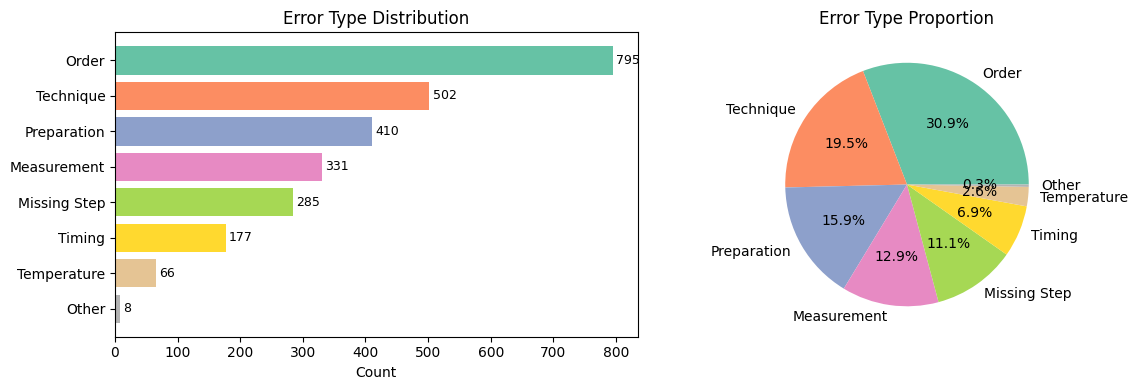

In [ ]:
# APPENDIX: Visualization of error distribution
import matplotlib.pyplot as plt
import numpy as np

sorted_errors = sorted(error_type_counts.items(), key=lambda x: -x[1])
labels = [e[0].replace(' Error', '') for e in sorted_errors]
counts = [e[1] for e in sorted_errors]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

# Bar chart
axes[0].barh(labels, counts, color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('Error Type Distribution')
axes[0].invert_yaxis()
for i, c in enumerate(counts):
    axes[0].text(c + 5, i, str(c), va='center', fontsize=9)

# Pie chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Error Type Proportion')

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()